# 4-figures

load, prepare and export figures for documentation and article 

In [1]:
import tools

## load template mri and template ct

In [2]:
def plot_and_save(A1, template_out, step=1, decimate=1, **params):
    for mode in ["sagittal", "coronal", "axial"]: 
        fig = tools.plot_slices(A1, mode, step=step, decimate=decimate, **params)
        fig.savefig(template_out.format(mode))
        tools.ext.plt.close()
        
def load_plot_and_save(fn_in, template_out, step=1, decimate=1, **params): 
    vol1 = tools.ext.nib.load(fn_in)
    A1 = vol1.get_fdata()
    plot_and_save(A1, template_out, step, decimate, cmap="gray", **params)
    del A1, vol1

In [3]:
fn1 = "../templates/template-phantom-mri_resolution-0100.nii.gz"
tpl1 = "../figs/raw/template-mri_resolution-0100_{0}.png"
load_plot_and_save(fn1, tpl1, 50, 10, vmin=0, vmax=1)

In [4]:
fn1 = "../templates/template-phantom-mri_resolution-1250.nii.gz"
tpl1 = "../figs/raw/template-mri_resolution-1250_{0}.png"
load_plot_and_save(fn1, tpl1, 5, 1, vmin=0, vmax=1)

In [5]:
fn1 = "../templates/template-phantom-ct_resolution-0100.nii.gz"
tpl1 = "../figs/raw/template-ct_resolution-0100_{0}.png"
load_plot_and_save(fn1, tpl1, 50, 10, vmin=0, vmax=1)

In [6]:
fn1 = "../templates/template-phantom-ct_resolution-1250.nii.gz"
tpl1 = "../figs/raw/template-ct_resolution-1250_{0}.png"
load_plot_and_save(fn1, tpl1, 5, 1, vmin=0, vmax=1)

In [7]:
fn1 = "../../../sub-1/ses-1/anat/sub-1_ses-1_T2w.nii.gz"
tpl1 = "../figs/raw/sub-1_ses-1_resolution-0391_{0}.png"
load_plot_and_save(fn1, tpl1, 12, 1, vmin=0, vmax=50)

In [8]:
fn1 = "../../../sub-1/ses-1/anat/sub-1_ses-1_T2w.nii.gz"
vol1 = tools.ext.nib.load(fn1)
A1 = vol1.get_fdata()

In [9]:
(A2, aff2) = tools.compute_subresolution_A1_aligned(
    A1, (0.391, 0.391, 0.391), (1.250, 1.250, 1.250), nrand=1000)

In [10]:
A2r = A2[:, :, 6:-2]

In [11]:
plot_and_save(A2r, "../figs/raw/sub-1_ses-1_resolution-1250_{0}.png", 4, 1, cmap="gray", vmin=0, vmax=50)

In [12]:
del A1, vol1, A2, A2r

In [13]:
fn1 = "../templates/template-phantom-mri_resolution-1250.nii.gz"
vol1 = tools.ext.nib.load(fn1)
A1 = vol1.get_fdata()

In [14]:
A1r = A1[5:-5, 5:-5, 5:-5]
A1r.shape

(39, 39, 39)

In [15]:
dic1 = tools.compute_patterns(A1r)

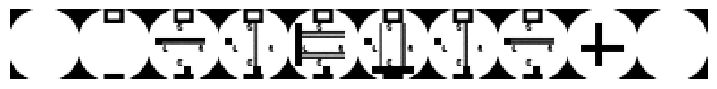

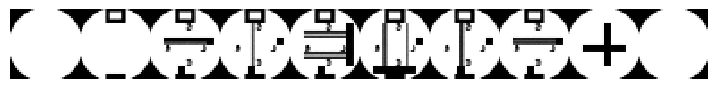

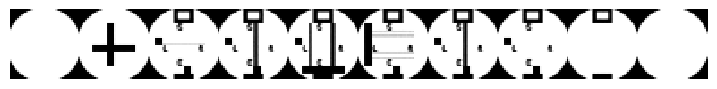

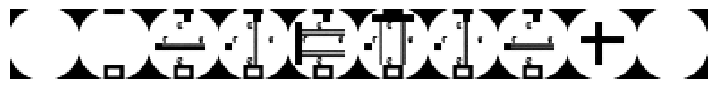

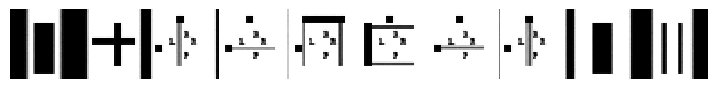

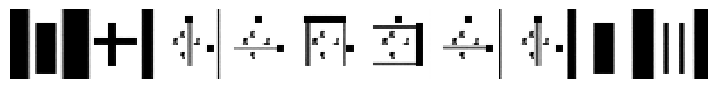

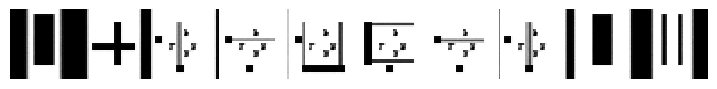

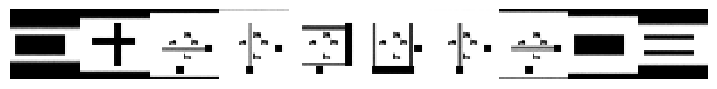

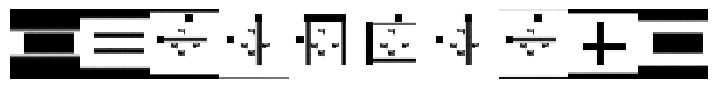

In [16]:
patterns = [
    "False_False_False_(0, 1, 2)", 
    "True_False_False_(0, 1, 2)", 
    "False_True_False_(0, 1, 2)", 
    "False_False_True_(0, 1, 2)", 
    "False_False_False_(0, 2, 1)", 
    "True_False_False_(0, 2, 1)",  
    "False_True_False_(0, 2, 1)",
    "False_False_False_(1, 2, 0)",
    "True_True_True_(1, 2, 0)"] 
    
            
for k in patterns:
    Ai = dic1[k]
    fig = tools.plot_slices(Ai, "coronal", step=4, decimate=1, cmap="gray", vmin=0, vmax=1)
    fig.savefig(f"../figs/pattern-{k}.png")
    # tools.ext.plt.close()